## 1. Importación de Librerías

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Carga y Exploración del Dataset

In [24]:
# Cargar el dataset
# OPCIÓN 1: Dataset original (desbalanceado)
# df = pd.read_csv('../resources/dataset/augmented_youtoxic_english_1000.csv', index_col=0)

# OPCIÓN 2: Dataset balanceado con data augmentation (RECOMENDADO)
# Descomenta la siguiente línea después de ejecutar data-augmentation-balancing.ipynb
import os
dataset_path_balanced = '../resources/dataset/augmented_youtoxic_balanced.csv'
dataset_path_original = '../resources/dataset/augmented_youtoxic_english_1000.csv'

if os.path.exists(dataset_path_balanced):
    df = pd.read_csv(dataset_path_balanced, index_col=0)
    print("✓ Usando dataset BALANCEADO con data augmentation")
else:
    df = pd.read_csv(dataset_path_original, index_col=0)
    print("⚠️  Usando dataset ORIGINAL (desbalanceado)")
    print("💡 Ejecuta 'data-augmentation-balancing.ipynb' para crear el dataset balanceado")

# Definir las etiquetas a usar
labels = ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']

print(f"\nForma del dataset: {df.shape}")
print(f"Etiquetas a analizar: {labels}")
print("\nPrimeras filas:")
df.head()

✓ Usando dataset BALANCEADO con data augmentation

Forma del dataset: (1476, 14)
Etiquetas a analizar: ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']

Primeras filas:


,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [25]:
# Información del dataset
print("Información del dataset:")
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas de las etiquetas:")
print(df[labels].describe())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 0 to 1475
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   VideoId          1476 non-null   object
 1   Text             1476 non-null   object
 2   IsToxic          1476 non-null   bool  
 3   IsAbusive        1476 non-null   bool  
 4   IsThreat         1476 non-null   bool  
 5   IsProvocative    1476 non-null   bool  
 6   IsObscene        1476 non-null   bool  
 7   IsHatespeech     1476 non-null   bool  
 8   IsRacist         1476 non-null   bool  
 9   IsNationalist    1476 non-null   bool  
 10  IsSexist         1476 non-null   bool  
 11  IsHomophobic     1476 non-null   bool  
 12  IsReligiousHate  1476 non-null   bool  
 13  IsRadicalism     1476 non-null   bool  
dtypes: bool(12), object(2)
memory usage: 51.9+ KB

Valores nulos por columna:
VideoId            0
Text               0
IsToxic            0
IsAbusive  

## 3. Análisis de Distribución de Etiquetas

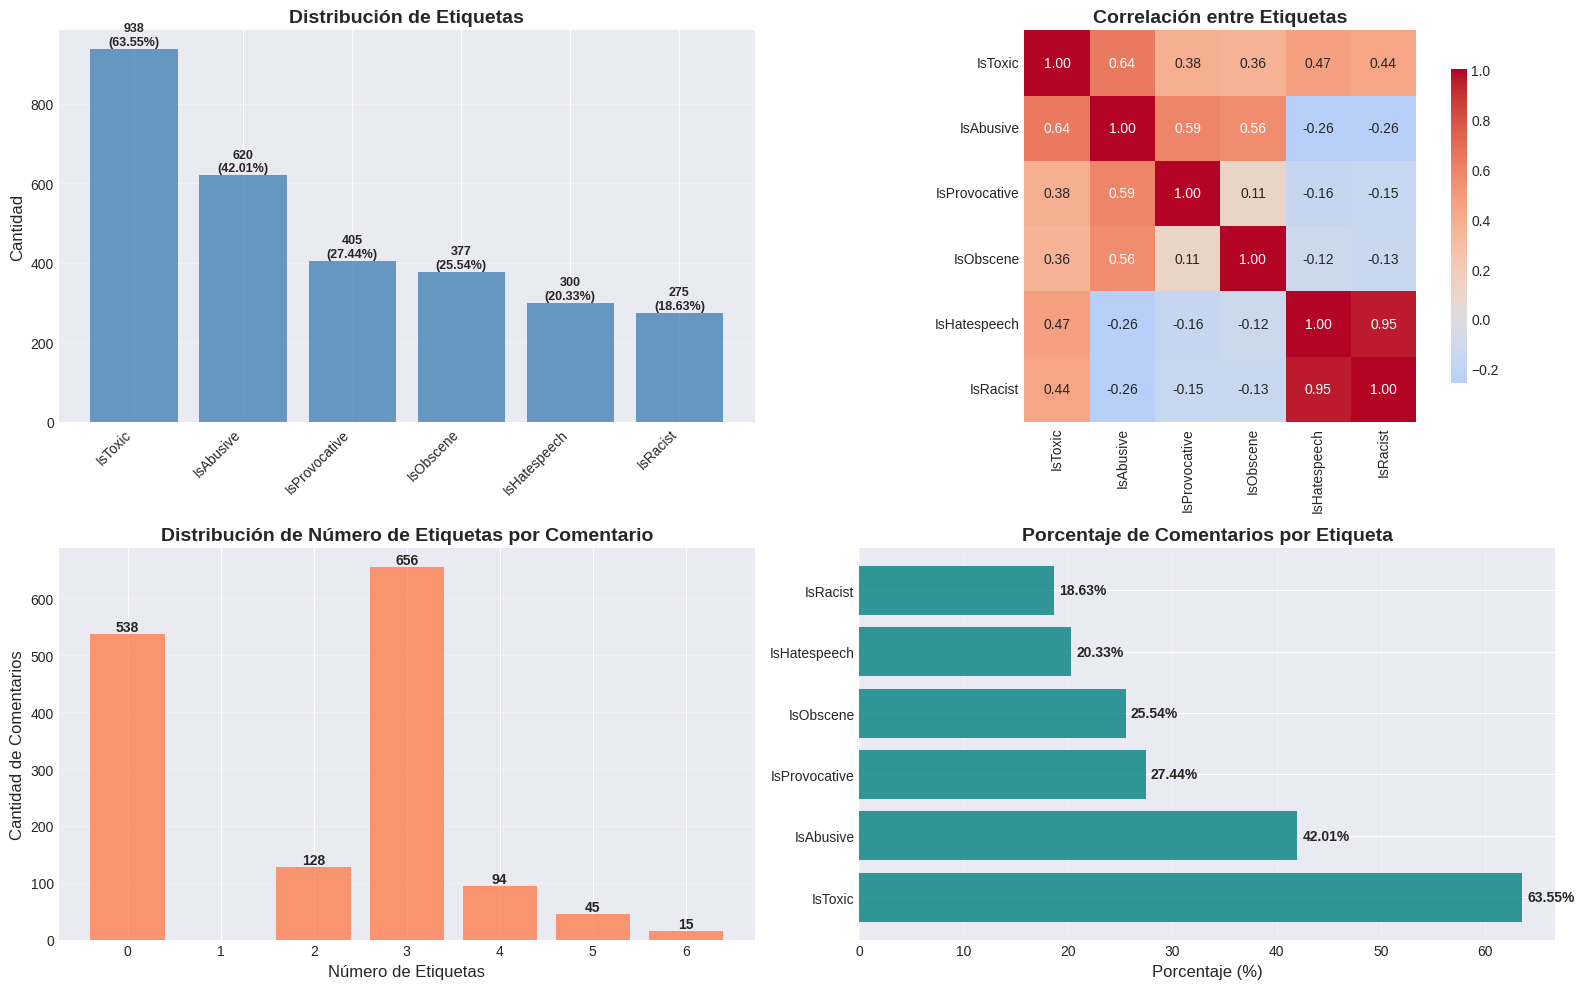


Balance del dataset:
IsToxic: 938 (63.55%)
IsAbusive: 620 (42.01%)
IsProvocative: 300 (20.33%)
IsObscene: 275 (18.63%)
IsHatespeech: 405 (27.44%)
IsRacist: 377 (25.54%)

Promedio de etiquetas por comentario: 1.97
Comentarios sin etiquetas: 538
Comentarios con al menos una etiqueta: 938


In [26]:
# Distribución de las etiquetas
label_counts = df[labels].sum().sort_values(ascending=False)
label_percentages = (label_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Gráfico 1: Conteo por etiqueta
axes[0].bar(range(len(labels)), label_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].set_title('Distribución de Etiquetas', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, f'{v}\n({label_percentages.values[i]}%)', ha='center', fontsize=9, fontweight='bold')

# Gráfico 2: Heatmap de correlaciones
corr_matrix = df[labels].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Correlación entre Etiquetas', fontsize=14, fontweight='bold')

# Gráfico 3: Distribución de número de etiquetas por comentario
num_labels = df[labels].sum(axis=1)
label_dist = num_labels.value_counts().sort_index()
axes[2].bar(label_dist.index, label_dist.values, color='coral', alpha=0.8)
axes[2].set_xlabel('Número de Etiquetas', fontsize=12)
axes[2].set_ylabel('Cantidad de Comentarios', fontsize=12)
axes[2].set_title('Distribución de Número de Etiquetas por Comentario', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, v in zip(label_dist.index, label_dist.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 4: Porcentaje de cada etiqueta
axes[3].barh(range(len(labels)), label_percentages.values, color='teal', alpha=0.8)
axes[3].set_yticks(range(len(labels)))
axes[3].set_yticklabels(labels)
axes[3].set_xlabel('Porcentaje (%)', fontsize=12)
axes[3].set_title('Porcentaje de Comentarios por Etiqueta', fontsize=14, fontweight='bold')
axes[3].grid(axis='x', alpha=0.3)
for i, v in enumerate(label_percentages.values):
    axes[3].text(v + 0.5, i, f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBalance del dataset:")
for label in labels:
    count = df[label].sum()
    pct = count / len(df) * 100
    print(f"{label}: {count} ({pct:.2f}%)")

print(f"\nPromedio de etiquetas por comentario: {num_labels.mean():.2f}")
print(f"Comentarios sin etiquetas: {(num_labels == 0).sum()}")
print(f"Comentarios con al menos una etiqueta: {(num_labels > 0).sum()}")

## 4. Análisis de Longitud de Texto

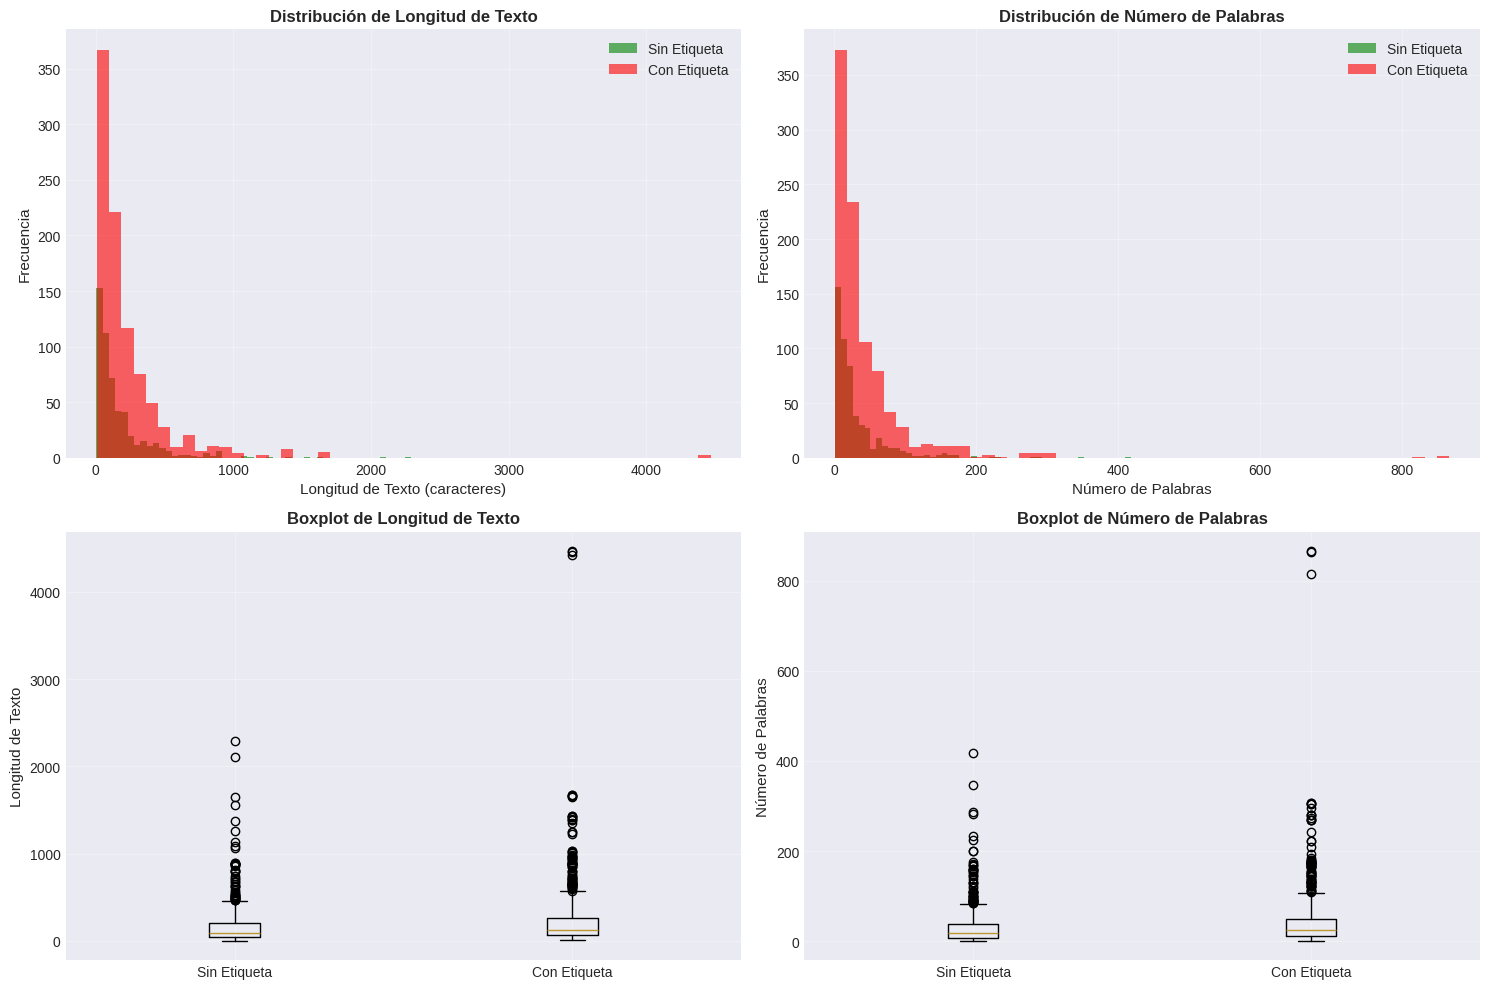


Estadísticas de texto por presencia de etiquetas:
          text_length                                                     \
                count        mean         std  min    25%    50%     75%   
has_label                                                                  
False           538.0  182.262082  252.295702  3.0  44.00   96.0  210.75   
True            938.0  231.466951  350.601090  6.0  65.25  130.5  267.00   

                  word_count                                               \
              max      count       mean        std  min   25%   50%   75%   
has_label                                                                   
False      2292.0      538.0  33.065056  45.165137  1.0   8.0  18.0  38.0   
True       4468.0      938.0  43.022388  66.382229  1.0  12.0  24.0  50.0   

                  
             max  
has_label         
False      418.0  
True       866.0  


In [27]:
# Análisis de longitud de texto
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

# Crear una columna indicando si tiene al menos una etiqueta
df['has_label'] = df[labels].sum(axis=1) > 0

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de longitud de texto
axes[0, 0].hist(df[df['has_label']==False]['text_length'], bins=50, alpha=0.6, label='Sin Etiqueta', color='green')
axes[0, 0].hist(df[df['has_label']==True]['text_length'], bins=50, alpha=0.6, label='Con Etiqueta', color='red')
axes[0, 0].set_xlabel('Longitud de Texto (caracteres)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].set_title('Distribución de Longitud de Texto', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Distribución de número de palabras
axes[0, 1].hist(df[df['has_label']==False]['word_count'], bins=50, alpha=0.6, label='Sin Etiqueta', color='green')
axes[0, 1].hist(df[df['has_label']==True]['word_count'], bins=50, alpha=0.6, label='Con Etiqueta', color='red')
axes[0, 1].set_xlabel('Número de Palabras', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Número de Palabras', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Boxplot de longitud de texto
axes[1, 0].boxplot([df[df['has_label']==False]['text_length'], df[df['has_label']==True]['text_length']],
                    labels=['Sin Etiqueta', 'Con Etiqueta'])
axes[1, 0].set_ylabel('Longitud de Texto', fontsize=11)
axes[1, 0].set_title('Boxplot de Longitud de Texto', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Boxplot de número de palabras
axes[1, 1].boxplot([df[df['has_label']==False]['word_count'], df[df['has_label']==True]['word_count']],
                    labels=['Sin Etiqueta', 'Con Etiqueta'])
axes[1, 1].set_ylabel('Número de Palabras', fontsize=11)
axes[1, 1].set_title('Boxplot de Número de Palabras', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEstadísticas de texto por presencia de etiquetas:")
print(df.groupby('has_label')[['text_length', 'word_count']].describe())

## 5. Preprocesamiento de Texto

In [28]:
def clean_text(text):
    """Limpia el texto para el procesamiento"""
    if pd.isna(text):
        return ""
    
    # Convertir a minúsculas
    text = text.lower()
    
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Eliminar menciones y hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Eliminar caracteres especiales y números (mantener letras y espacios)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Aplicar limpieza
print("Limpiando texto...")
df['cleaned_text'] = df['Text'].apply(clean_text)

# Eliminar filas con texto vacío
df = df[df['cleaned_text'].str.len() > 0]

print(f"Filas después de limpieza: {len(df)}")
print("\nEjemplos de texto limpio:")
for i in range(3):
    print(f"\nOriginal: {df.iloc[i]['Text'][:100]}...")
    print(f"Limpio: {df.iloc[i]['cleaned_text'][:100]}...")

Limpiando texto...
Filas después de limpieza: 1474

Ejemplos de texto limpio:

Original: If only people would just take a step back and not make this case about them, because it wasn't abou...
Limpio: if only people would just take a step back and not make this case about them because it wasnt about ...

Original: Law enforcement is not trained to shoot to apprehend.  They are trained to shoot to kill.  And I tha...
Limpio: law enforcement is not trained to shoot to apprehend they are trained to shoot to kill and i thank w...

Original: 
Dont you reckon them 'black lives matter' banners being held by white cunts is  kinda patronizing a...
Limpio: dont you reckon them black lives matter banners being held by white cunts is kinda patronizing and i...


## 6. División del Dataset

In [29]:
# Preparar X e y
X = df['cleaned_text']
y = df[labels].astype(int)

# División del dataset (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño del conjunto de prueba: {len(X_test)}")
print(f"\nDistribución de etiquetas en train:")
print(y_train.sum())
print(f"\nDistribución de etiquetas en test:")
print(y_test.sum())

Tamaño del conjunto de entrenamiento: 1179
Tamaño del conjunto de prueba: 295

Distribución de etiquetas en train:
IsToxic          753
IsAbusive        484
IsProvocative    228
IsObscene        216
IsHatespeech     333
IsRacist         311
dtype: int64

Distribución de etiquetas en test:
IsToxic          184
IsAbusive        136
IsProvocative     72
IsObscene         59
IsHatespeech      71
IsRacist          65
dtype: int64


## 7. Vectorización con TF-IDF

In [30]:
# Vectorización TF-IDF con parámetros para evitar overfitting
tfidf = TfidfVectorizer(
    max_features=5000,  # Limitar características para evitar overfitting
    min_df=2,           # Ignorar términos muy raros
    max_df=0.8,         # Ignorar términos muy comunes
    ngram_range=(1, 2), # Unigramas y bigramas
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

print("Vectorizando texto con TF-IDF...")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nForma de X_train_tfidf: {X_train_tfidf.shape}")
print(f"Forma de X_test_tfidf: {X_test_tfidf.shape}")
print(f"\nNúmero de características: {len(tfidf.get_feature_names_out())}")

Vectorizando texto con TF-IDF...

Forma de X_train_tfidf: (1179, 5000)
Forma de X_test_tfidf: (295, 5000)

Número de características: 5000


## 8. Entrenamiento del Modelo SVM Multi-Etiqueta

### 8.1 Modelo Base

In [45]:
# Entrenar modelo SVM multi-etiqueta con regularización
# Usamos OneVsRestClassifier para clasificación multi-etiqueta
print("Entrenando modelo SVM multi-etiqueta...")

# C más bajo = más regularización = menos overfitting
# class_weight='balanced' ajusta automáticamente los pesos para clases desbalanceadas
base_svm = LinearSVC(C=0.1, class_weight='balanced', random_state=42, max_iter=2000, dual=False)
svm_multilabel = OneVsRestClassifier(base_svm)

svm_multilabel.fit(X_train_tfidf, y_train)

# Predicciones
y_train_pred = svm_multilabel.predict(X_train_tfidf)
y_test_pred = svm_multilabel.predict(X_test_tfidf)

print("✓ Modelo entrenado")

Entrenando modelo SVM multi-etiqueta...
✓ Modelo entrenado


### 8.2 Evaluación por Etiqueta

In [46]:
# Función para evaluar cada etiqueta
def evaluate_multilabel_model(y_train_true, y_train_pred, y_test_true, y_test_pred, label_names):
    """Evalúa el modelo multi-etiqueta y muestra métricas por etiqueta"""
    
    results = []
    
    print(f"\n{'='*90}")
    print(f"EVALUACIÓN DEL MODELO MULTI-ETIQUETA")
    print(f"{'='*90}")
    
    print(f"\n{'Etiqueta':<15} {'Train Acc':>10} {'Test Acc':>10} {'Train F1':>10} {'Test F1':>10} {'Diff Acc':>12} {'Diff F1':>12}")
    print("-" * 90)
    
    for i, label in enumerate(label_names):
        # Métricas de entrenamiento
        train_acc = accuracy_score(y_train_true.iloc[:, i], y_train_pred[:, i])
        train_f1 = f1_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        train_prec = precision_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        train_rec = recall_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        
        # Métricas de test
        test_acc = accuracy_score(y_test_true.iloc[:, i], y_test_pred[:, i])
        test_f1 = f1_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        test_prec = precision_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        test_rec = recall_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        
        # Diferencias
        diff_acc = abs(train_acc - test_acc) * 100
        diff_f1 = abs(train_f1 - test_f1) * 100
        
        print(f"{label:<15} {train_acc:>10.4f} {test_acc:>10.4f} {train_f1:>10.4f} {test_f1:>10.4f} {diff_acc:>11.2f}% {diff_f1:>11.2f}%")
        
        results.append({
            'label': label,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'train_f1': train_f1,
            'test_f1': test_f1,
            'train_prec': train_prec,
            'test_prec': test_prec,
            'train_rec': train_rec,
            'test_rec': test_rec,
            'diff_acc': diff_acc,
            'diff_f1': diff_f1
        })
    
    print("-" * 90)
    
    # Métricas globales
    hamming_train = hamming_loss(y_train_true, y_train_pred)
    hamming_test = hamming_loss(y_test_true, y_test_pred)
    
    print(f"\nMÉTRICAS GLOBALES:")
    print(f"Hamming Loss Train: {hamming_train:.4f}")
    print(f"Hamming Loss Test:  {hamming_test:.4f}")
    print(f"Diferencia: {abs(hamming_train - hamming_test)*100:.2f}%")
    
    # Verificar overfitting
    max_diff_acc = max([r['diff_acc'] for r in results])
    max_diff_f1 = max([r['diff_f1'] for r in results])
    max_diff = max(max_diff_acc, max_diff_f1)
    
    print(f"\nANÁLISIS DE OVERFITTING:")
    print(f"Diferencia máxima en Accuracy: {max_diff_acc:.2f}%")
    print(f"Diferencia máxima en F1-Score: {max_diff_f1:.2f}%")
    
    if max_diff < 5:
        print(f"\n✓ NO HAY OVERFITTING (diferencia máxima: {max_diff:.2f}%)")
    else:
        print(f"\n⚠ POSIBLE OVERFITTING (diferencia máxima: {max_diff:.2f}%)")
    
    print(f"\n{'='*90}\n")
    
    return pd.DataFrame(results)

results_df = evaluate_multilabel_model(y_train, y_train_pred, y_test, y_test_pred, labels)


EVALUACIÓN DEL MODELO MULTI-ETIQUETA

Etiqueta         Train Acc   Test Acc   Train F1    Test F1     Diff Acc      Diff F1
------------------------------------------------------------------------------------------
IsToxic             0.9440     0.7797     0.9558     0.8294       16.44%       12.64%
IsAbusive           0.9550     0.8237     0.9450     0.7969       13.13%       14.81%
IsProvocative       0.9754     0.9017     0.9389     0.7883        7.37%       15.06%
IsObscene           0.9856     0.9492     0.9615     0.8696        3.64%        9.19%
IsHatespeech        0.9652     0.9288     0.9412     0.8591        3.64%        8.21%
IsRacist            0.9661     0.9322     0.9390     0.8571        3.39%        8.19%
------------------------------------------------------------------------------------------

MÉTRICAS GLOBALES:
Hamming Loss Train: 0.0348
Hamming Loss Test:  0.1141
Diferencia: 7.93%

ANÁLISIS DE OVERFITTING:
Diferencia máxima en Accuracy: 16.44%
Diferencia máxima en 

## 9. Visualización de Resultados

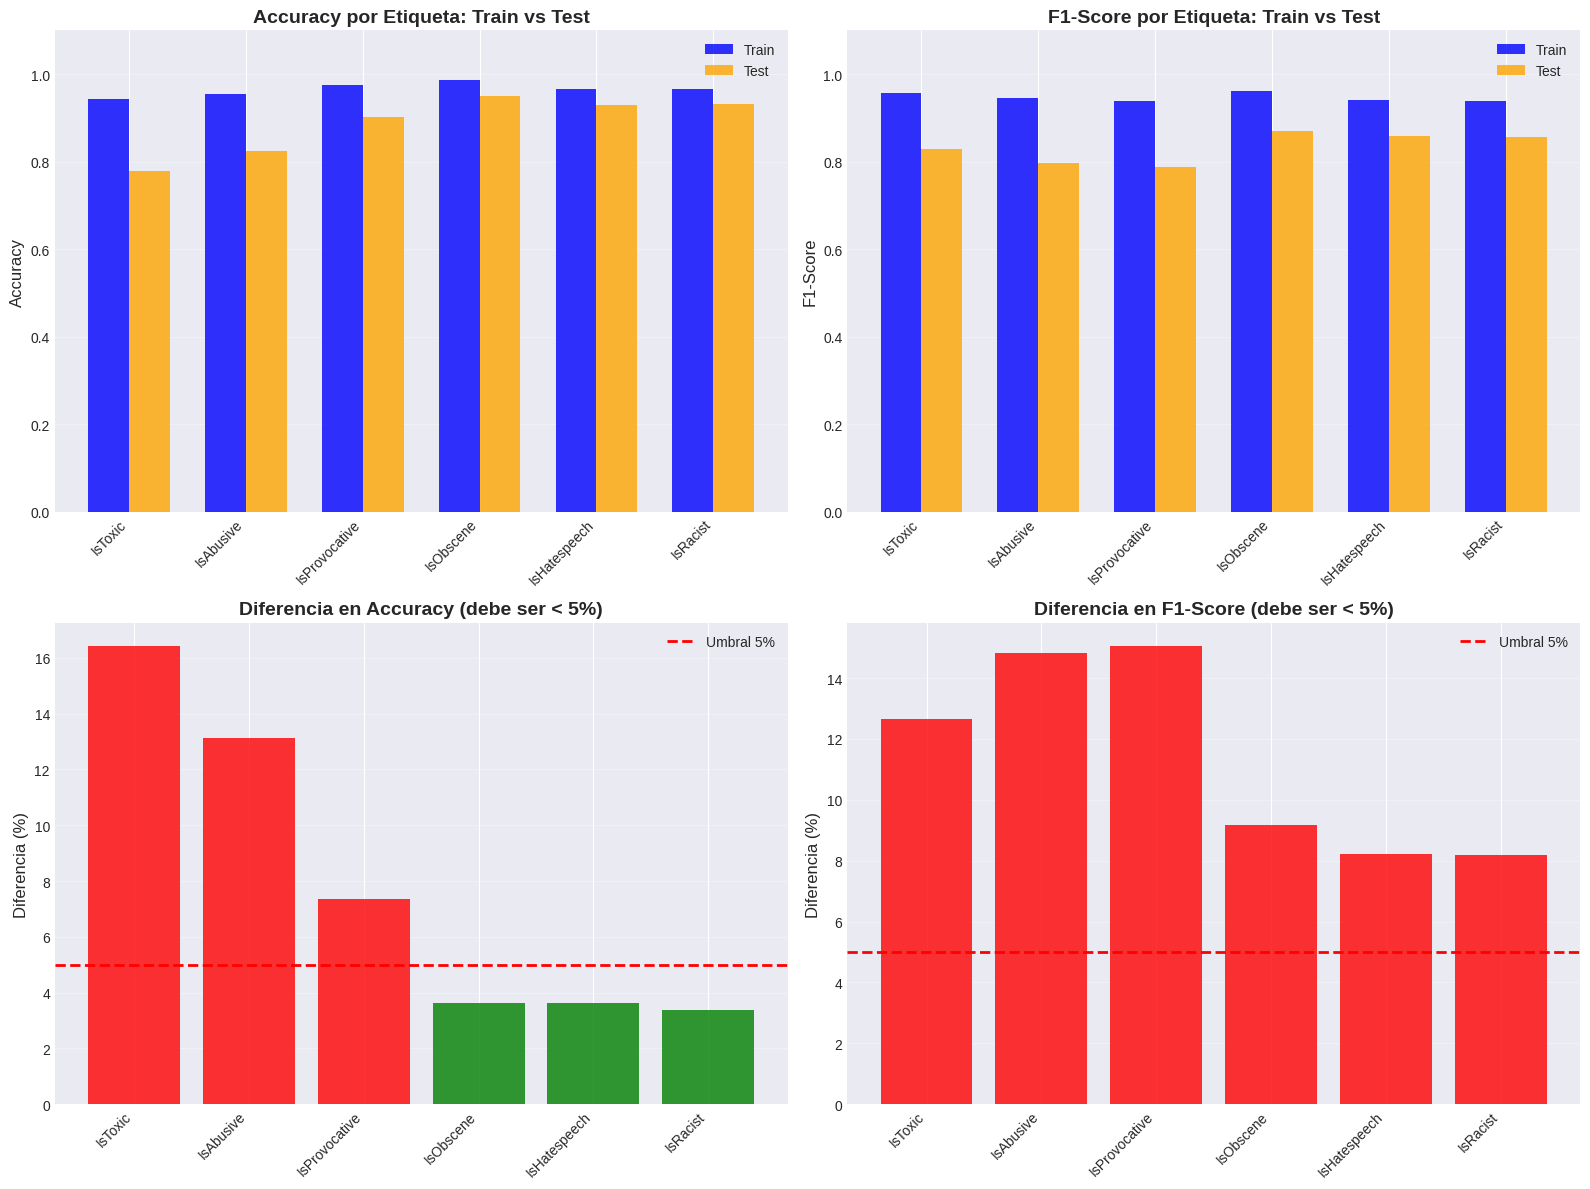

In [33]:
# Gráfico de comparación de métricas por etiqueta
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy por etiqueta
x = np.arange(len(labels))
width = 0.35

axes[0, 0].bar(x - width/2, results_df['train_acc'], width, label='Train', alpha=0.8, color='blue')
axes[0, 0].bar(x + width/2, results_df['test_acc'], width, label='Test', alpha=0.8, color='orange')
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy por Etiqueta: Train vs Test', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1.1])

# F1-Score por etiqueta
axes[0, 1].bar(x - width/2, results_df['train_f1'], width, label='Train', alpha=0.8, color='blue')
axes[0, 1].bar(x + width/2, results_df['test_f1'], width, label='Test', alpha=0.8, color='orange')
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score por Etiqueta: Train vs Test', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(labels, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0, 1.1])

# Diferencias en Accuracy
colors_acc = ['green' if d < 5 else 'red' for d in results_df['diff_acc']]
axes[1, 0].bar(labels, results_df['diff_acc'], alpha=0.8, color=colors_acc)
axes[1, 0].axhline(y=5, color='red', linestyle='--', linewidth=2, label='Umbral 5%')
axes[1, 0].set_ylabel('Diferencia (%)', fontsize=12)
axes[1, 0].set_title('Diferencia en Accuracy (debe ser < 5%)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(labels, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Diferencias en F1-Score
colors_f1 = ['green' if d < 5 else 'red' for d in results_df['diff_f1']]
axes[1, 1].bar(labels, results_df['diff_f1'], alpha=0.8, color=colors_f1)
axes[1, 1].axhline(y=5, color='red', linestyle='--', linewidth=2, label='Umbral 5%')
axes[1, 1].set_ylabel('Diferencia (%)', fontsize=12)
axes[1, 1].set_title('Diferencia en F1-Score (debe ser < 5%)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(labels, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

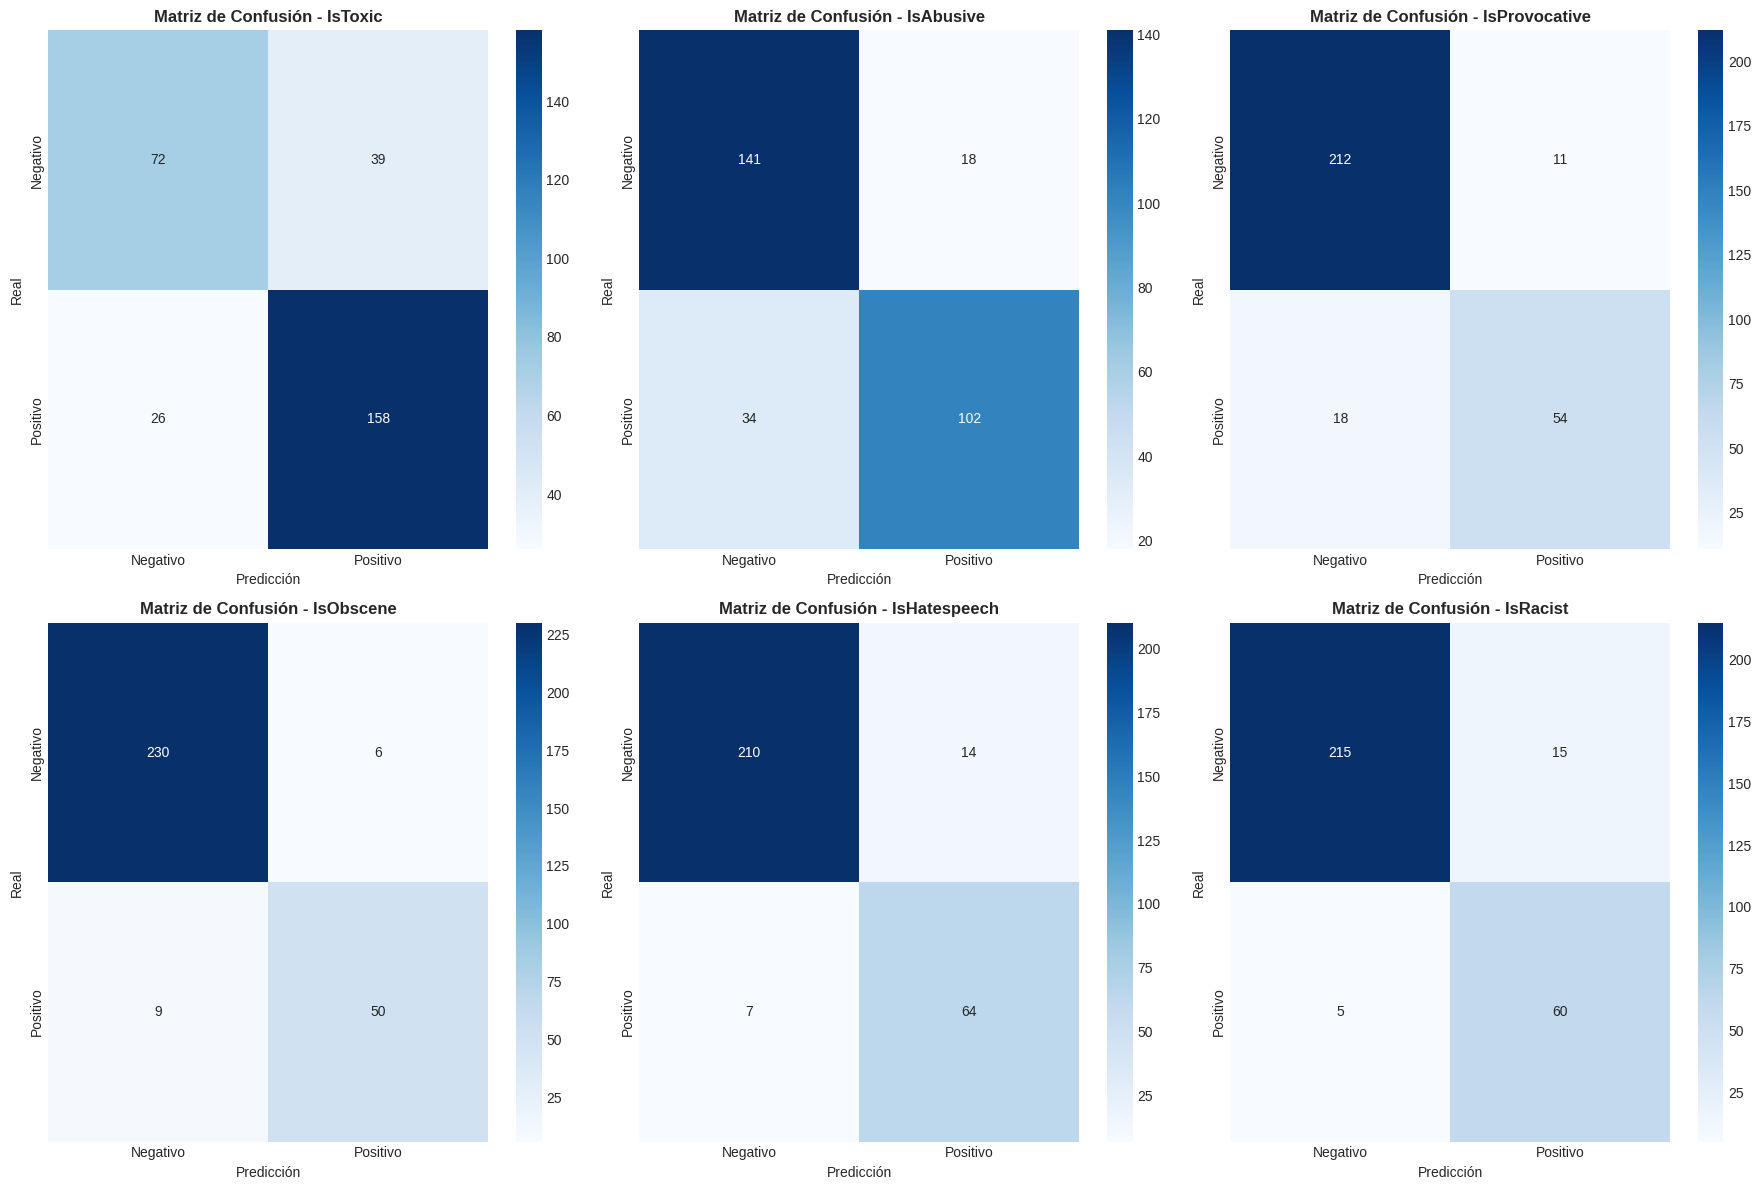

In [34]:
# Matrices de confusión para cada etiqueta
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, label in enumerate(labels):
    cm = confusion_matrix(y_test.iloc[:, i], y_test_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])
    axes[i].set_title(f'Matriz de Confusión - {label}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Real', fontsize=10)
    axes[i].set_xlabel('Predicción', fontsize=10)

plt.tight_layout()
plt.show()

## 10. Reportes de Clasificación Detallados

In [35]:
# Reportes de clasificación por etiqueta
for i, label in enumerate(labels):
    print(f"\n{'='*70}")
    print(f"REPORTE DE CLASIFICACIÓN - {label}")
    print(f"{'='*70}")
    
    print(f"\nTrain:")
    print(classification_report(y_train.iloc[:, i], y_train_pred[:, i], 
                                target_names=['Negativo', 'Positivo'],
                                digits=4, zero_division=0))
    
    print(f"\nTest:")
    print(classification_report(y_test.iloc[:, i], y_test_pred[:, i], 
                                target_names=['Negativo', 'Positivo'],
                                digits=4, zero_division=0))


REPORTE DE CLASIFICACIÓN - IsToxic

Train:
              precision    recall  f1-score   support

    Negativo     0.9110    0.9366    0.9236       426
    Positivo     0.9636    0.9482    0.9558       753

    accuracy                         0.9440      1179
   macro avg     0.9373    0.9424    0.9397      1179
weighted avg     0.9446    0.9440    0.9442      1179


Test:
              precision    recall  f1-score   support

    Negativo     0.7347    0.6486    0.6890       111
    Positivo     0.8020    0.8587    0.8294       184

    accuracy                         0.7797       295
   macro avg     0.7684    0.7537    0.7592       295
weighted avg     0.7767    0.7797    0.7766       295


REPORTE DE CLASIFICACIÓN - IsAbusive

Train:
              precision    recall  f1-score   support

    Negativo     0.9586    0.9655    0.9620       695
    Positivo     0.9499    0.9401    0.9450       484

    accuracy                         0.9550      1179
   macro avg     0.9542    0.95

## 11. Análisis de Coocurrencia de Etiquetas

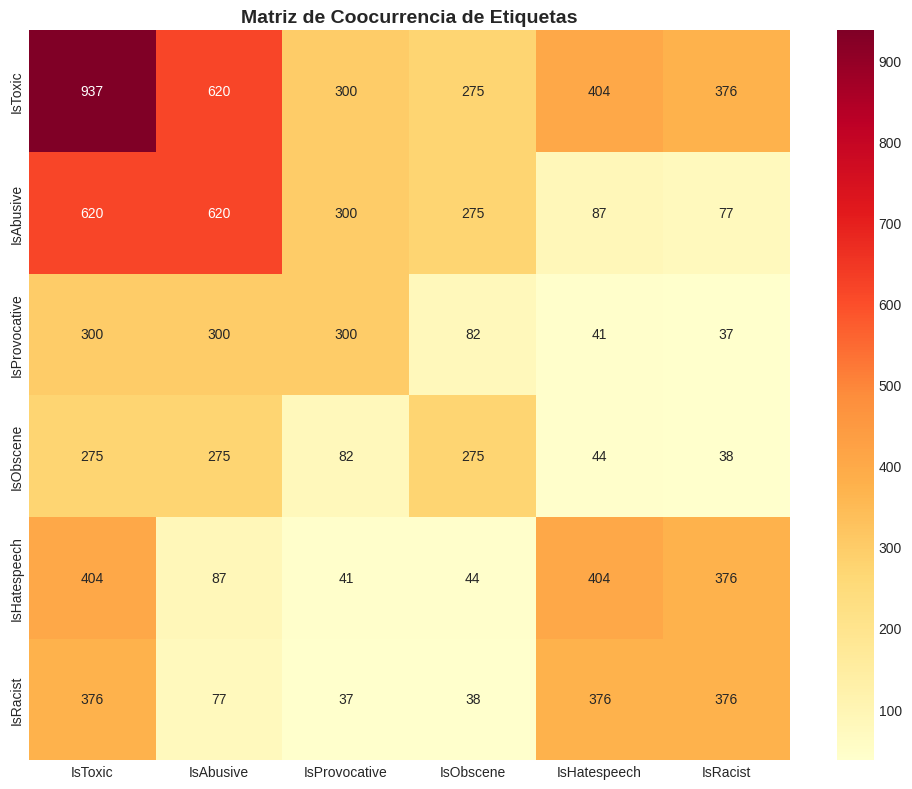


Combinaciones de etiquetas más frecuentes:
IsToxic + IsAbusive: 620
IsToxic + IsProvocative: 300
IsToxic + IsObscene: 275
IsToxic + IsHatespeech: 404
IsToxic + IsRacist: 376
IsAbusive + IsProvocative: 300
IsAbusive + IsObscene: 275
IsAbusive + IsHatespeech: 87
IsAbusive + IsRacist: 77
IsProvocative + IsObscene: 82
IsProvocative + IsHatespeech: 41
IsProvocative + IsRacist: 37
IsObscene + IsHatespeech: 44
IsObscene + IsRacist: 38
IsHatespeech + IsRacist: 376


In [36]:
# Matriz de coocurrencia de etiquetas
cooccurrence = np.zeros((len(labels), len(labels)))

for i in range(len(labels)):
    for j in range(len(labels)):
        cooccurrence[i, j] = ((df[labels[i]] == 1) & (df[labels[j]] == 1)).sum()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooccurrence, annot=True, fmt='.0f', cmap='YlOrRd', 
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title('Matriz de Coocurrencia de Etiquetas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCombinaciones de etiquetas más frecuentes:")
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        count = cooccurrence[i, j]
        if count > 0:
            print(f"{labels[i]} + {labels[j]}: {int(count)}")

## 12. Optimización de Hiperparámetros (Opcional)

In [37]:
# Grid Search para encontrar mejores parámetros
print("Buscando mejores hiperparámetros...")

param_grid = {
    'estimator__C': [0.01, 0.1, 0.5, 1.0],  # Valores de regularización
    'estimator__class_weight': [None, 'balanced']  # Manejo de clases desbalanceadas
}

base_svm_grid = LinearSVC(random_state=42, max_iter=2000, dual=False)
svm_multilabel_grid = OneVsRestClassifier(base_svm_grid)

# Usar F1 macro como métrica
grid_search = GridSearchCV(
    svm_multilabel_grid,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")
print(f"Mejor F1-Score Macro (CV): {grid_search.best_score_:.4f}")

Buscando mejores hiperparámetros...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Mejores parámetros encontrados: {'estimator__C': 1.0, 'estimator__class_weight': None}
Mejor F1-Score Macro (CV): 0.7837

Mejores parámetros encontrados: {'estimator__C': 1.0, 'estimator__class_weight': None}
Mejor F1-Score Macro (CV): 0.7837


In [38]:
# Evaluar modelo optimizado
print("\nEvaluando modelo optimizado...")
svm_optimized = grid_search.best_estimator_

y_train_pred_opt = svm_optimized.predict(X_train_tfidf)
y_test_pred_opt = svm_optimized.predict(X_test_tfidf)

results_opt_df = evaluate_multilabel_model(y_train, y_train_pred_opt, y_test, y_test_pred_opt, labels)


Evaluando modelo optimizado...

EVALUACIÓN DEL MODELO MULTI-ETIQUETA

Etiqueta         Train Acc   Test Acc   Train F1    Test F1     Diff Acc      Diff F1
------------------------------------------------------------------------------------------
IsToxic             0.9890     0.8169     0.9914     0.8657       17.20%       12.57%
IsAbusive           0.9907     0.8678     0.9886     0.8494       12.29%       13.91%
IsProvocative       0.9932     0.9119     0.9823     0.7869        8.14%       19.54%
IsObscene           0.9958     0.9458     0.9884     0.8519        5.00%       13.65%
IsHatespeech        0.9966     0.9593     0.9940     0.9155        3.73%        7.85%
IsRacist            0.9966     0.9559     0.9935     0.9008        4.07%        9.28%
------------------------------------------------------------------------------------------

MÉTRICAS GLOBALES:
Hamming Loss Train: 0.0064
Hamming Loss Test:  0.0904
Diferencia: 8.40%

ANÁLISIS DE OVERFITTING:
Diferencia máxima en Accura

## 13. Ejemplos de Predicciones

In [39]:
# Función para predecir y mostrar resultados
def predict_multilabel(text, model, vectorizer, label_names):
    """Predice etiquetas para un texto dado"""
    # Usar la función clean_text ya definida en el notebook
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    predictions = model.predict(vectorized)[0]
    
    print(f"\nTexto: {text[:200]}...")
    print(f"\nEtiquetas predichas:")
    for i, label in enumerate(label_names):
        if predictions[i] == 1:
            print(f"  ✓ {label}")
    
    if predictions.sum() == 0:
        print("  (Sin etiquetas)")
    
    print("-" * 80)

# Ejemplos del conjunto de test
print("\n" + "="*80)
print("EJEMPLOS DE PREDICCIONES")
print("="*80)

import random
random.seed(42)
sample_indices = random.sample(range(len(X_test)), 5)

for idx in sample_indices:
    text = X_test.iloc[idx]
    true_labels = y_test.iloc[idx]
    
    print(f"\nEtiquetas Reales:")
    real_labels = [labels[i] for i in range(len(labels)) if true_labels.iloc[i] == 1]
    if real_labels:
        for label in real_labels:
            print(f"  ✓ {label}")
    else:
        print("  (Sin etiquetas)")
    
    predict_multilabel(text, svm_multilabel, tfidf, labels)


EJEMPLOS DE PREDICCIONES

Etiquetas Reales:
  ✓ IsToxic
  ✓ IsAbusive
  ✓ IsObscene

Texto: what a piece of ass douche travelling bag...

Etiquetas predichas:
  ✓ IsToxic
  ✓ IsAbusive
  ✓ IsObscene
--------------------------------------------------------------------------------

Etiquetas Reales:
  ✓ IsToxic
  ✓ IsAbusive
  ✓ IsHatespeech
  ✓ IsRacist

Texto: omg these dumbass protesters are preventing cops to do their job because of their whining i really really hate people who protest like this edit look at that ugly ass black girl with the big eyes...

Etiquetas predichas:
  ✓ IsToxic
  ✓ IsAbusive
  ✓ IsHatespeech
  ✓ IsRacist
--------------------------------------------------------------------------------

Etiquetas Reales:
  (Sin etiquetas)

Texto: lol at police in the begining sounds more like hes saying moo then move but that cow i mean cop maybe feel more like a cop i mean cow...

Etiquetas predichas:
  (Sin etiquetas)
--------------------------------------------------------

## 14. Resumen Final

In [40]:
print("\n" + "="*80)
print("RESUMEN FINAL DEL MODELO SVM MULTI-ETIQUETA")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   - Total de muestras: {len(df)}")
print(f"   - Entrenamiento: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"   - Prueba: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"   - Número de etiquetas: {len(labels)}")

print(f"\n🏷️  Etiquetas:")
for label in labels:
    count = df[label].sum()
    pct = count / len(df) * 100
    print(f"   - {label}: {count} ({pct:.2f}%)")

print(f"\n🔧 Configuración del Modelo:")
print(f"   - Algoritmo: Support Vector Machine (LinearSVC)")
print(f"   - Estrategia: OneVsRestClassifier (Multi-Etiqueta)")
print(f"   - Vectorización: TF-IDF (max_features={tfidf.max_features})")
print(f"   - Regularización C: {svm_multilabel.estimator.C}")

print(f"\n📈 Resumen de Métricas por Etiqueta (Test):")
print(f"\n{'Etiqueta':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['label']:<15} {row['test_acc']:>10.4f} {row['test_prec']:>10.4f} {row['test_rec']:>10.4f} {row['test_f1']:>10.4f}")

print(f"\n⚠️  Análisis de Overfitting:")
max_diff = max(results_df['diff_acc'].max(), results_df['diff_f1'].max())
if max_diff < 5:
    print(f"   ✓ NO HAY OVERFITTING")
    print(f"   ✓ Diferencia máxima: {max_diff:.2f}% (objetivo: < 5%)")
else:
    print(f"   ⚠ POSIBLE OVERFITTING DETECTADO")
    print(f"   ⚠ Diferencia máxima: {max_diff:.2f}% (objetivo: < 5%)")

# Promedios
avg_test_acc = results_df['test_acc'].mean()
avg_test_f1 = results_df['test_f1'].mean()

print(f"\n🎯 Promedios (Test):")
print(f"   Accuracy promedio: {avg_test_acc:.4f}")
print(f"   F1-Score promedio: {avg_test_f1:.4f}")

print("\n" + "="*80)
print("✓ Análisis completado exitosamente")
print("="*80)


RESUMEN FINAL DEL MODELO SVM MULTI-ETIQUETA

📊 Dataset:
   - Total de muestras: 1474
   - Entrenamiento: 1179 (80.0%)
   - Prueba: 295 (20.0%)
   - Número de etiquetas: 6

🏷️  Etiquetas:
   - IsToxic: 937 (63.57%)
   - IsAbusive: 620 (42.06%)
   - IsProvocative: 300 (20.35%)
   - IsObscene: 275 (18.66%)
   - IsHatespeech: 404 (27.41%)
   - IsRacist: 376 (25.51%)

🔧 Configuración del Modelo:
   - Algoritmo: Support Vector Machine (LinearSVC)
   - Estrategia: OneVsRestClassifier (Multi-Etiqueta)
   - Vectorización: TF-IDF (max_features=5000)
   - Regularización C: 0.1

📈 Resumen de Métricas por Etiqueta (Test):

Etiqueta          Accuracy  Precision     Recall   F1-Score
-----------------------------------------------------------------
IsToxic             0.7797     0.8020     0.8587     0.8294
IsAbusive           0.8237     0.8500     0.7500     0.7969
IsProvocative       0.9017     0.8308     0.7500     0.7883
IsObscene           0.9492     0.8929     0.8475     0.8696
IsHatespeech   

## 15. Resumen Visual de Resultados Clave


                                   📊 RESULTADOS FINALES 📊

🎯 F1-SCORE POR ETIQUETA:

Etiqueta                 Train F1      Test F1      Diferencia               Estado
----------------------------------------------------------------------------------------------------
IsToxic                    0.9558       0.8294          12.64% 🔴       ⚠ REVISAR
IsAbusive                  0.9450       0.7969          14.81% 🔴       ⚠ REVISAR
IsProvocative              0.9389       0.7883          15.06% 🔴       ⚠ REVISAR
IsObscene                  0.9615       0.8696           9.19% 🔴       ⚠ REVISAR
IsHatespeech               0.9412       0.8591           8.21% 🔴       ⚠ REVISAR
IsRacist                   0.9390       0.8571           8.19% 🔴       ⚠ REVISAR
----------------------------------------------------------------------------------------------------
PROMEDIO                   0.9469       0.8334          11.35%


⚠️  ANÁLISIS DE OVERFITTING (Objetivo: Diferencia < 5%):
--------------------

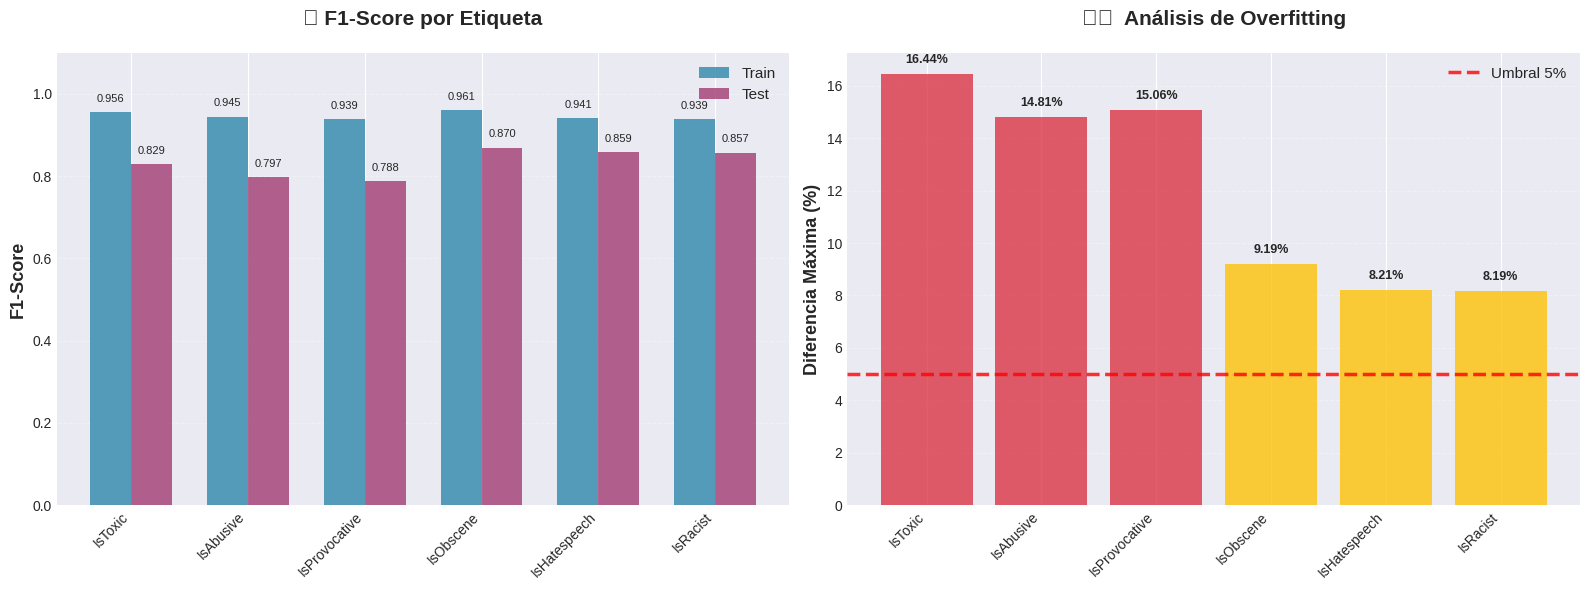


✅ Análisis completado. Revisa los gráficos y tablas arriba para los resultados completos.


In [47]:
# Tabla resumida de F1-Score y Overfitting
print("\n" + "="*100)
print(" "*35 + "📊 RESULTADOS FINALES 📊")
print("="*100)

print("\n🎯 F1-SCORE POR ETIQUETA:")
print(f"\n{'Etiqueta':<20} {'Train F1':>12} {'Test F1':>12} {'Diferencia':>15} {'Estado':>20}")
print("-" * 100)

for _, row in results_df.iterrows():
    diff = row['diff_f1']
    estado = "✓ OK" if diff < 5 else "⚠ REVISAR"
    color_indicator = "🟢" if diff < 5 else "🔴"
    print(f"{row['label']:<20} {row['train_f1']:>12.4f} {row['test_f1']:>12.4f} {diff:>14.2f}% {color_indicator} {estado:>15}")

print("-" * 100)

# Promedio F1
avg_train_f1 = results_df['train_f1'].mean()
avg_test_f1 = results_df['test_f1'].mean()
avg_diff_f1 = abs(avg_train_f1 - avg_test_f1) * 100

print(f"{'PROMEDIO':<20} {avg_train_f1:>12.4f} {avg_test_f1:>12.4f} {avg_diff_f1:>14.2f}%")

# Análisis de Overfitting
print("\n" + "="*100)
print("\n⚠️  ANÁLISIS DE OVERFITTING (Objetivo: Diferencia < 5%):")
print("-" * 100)

overfitting_data = []
for _, row in results_df.iterrows():
    overfitting_data.append({
        'Etiqueta': row['label'],
        'Diff Accuracy (%)': row['diff_acc'],
        'Diff F1-Score (%)': row['diff_f1'],
        'Max Diff (%)': max(row['diff_acc'], row['diff_f1'])
    })

overfitting_df = pd.DataFrame(overfitting_data).sort_values('Max Diff (%)', ascending=False)

for _, row in overfitting_df.iterrows():
    max_diff = row['Max Diff (%)']
    if max_diff < 5:
        status = "✓ Excelente (Sin overfitting)"
        icon = "🟢"
    elif max_diff < 10:
        status = "⚠ Aceptable (Overfitting leve)"
        icon = "🟡"
    else:
        status = "❌ Revisar (Overfitting significativo)"
        icon = "🔴"
    
    print(f"{icon} {row['Etiqueta']:<15} | Acc Diff: {row['Diff Accuracy (%)']:>6.2f}% | F1 Diff: {row['Diff F1-Score (%)']:>6.2f}% | {status}")

print("-" * 100)

# Veredicto final
max_diff_global = max(results_df['diff_acc'].max(), results_df['diff_f1'].max())
etiquetas_con_overfitting = results_df[(results_df['diff_acc'] >= 5) | (results_df['diff_f1'] >= 5)]

print("\n" + "="*100)
print("🏆 VEREDICTO FINAL:")
print("="*100)

if max_diff_global < 5:
    print(f"\n✅ ¡EXCELENTE! El modelo NO presenta overfitting")
    print(f"   Diferencia máxima detectada: {max_diff_global:.2f}% (Objetivo: < 5%)")
    print(f"   Todas las {len(labels)} etiquetas cumplen con el criterio.")
else:
    print(f"\n⚠️  El modelo presenta overfitting en algunas etiquetas")
    print(f"   Diferencia máxima detectada: {max_diff_global:.2f}% (Objetivo: < 5%)")
    print(f"   Etiquetas con overfitting: {len(etiquetas_con_overfitting)} de {len(labels)}")
    print(f"\n   Etiquetas problemáticas:")
    for _, row in etiquetas_con_overfitting.iterrows():
        print(f"      - {row['label']}: Acc Diff={row['diff_acc']:.2f}%, F1 Diff={row['diff_f1']:.2f}%")

print("\n" + "="*100)

# Gráfico visual compacto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: F1-Score comparativo
x_pos = np.arange(len(labels))
width = 0.35

bars1 = axes[0].bar(x_pos - width/2, results_df['train_f1'], width, label='Train', alpha=0.8, color='#2E86AB')
bars2 = axes[0].bar(x_pos + width/2, results_df['test_f1'], width, label='Test', alpha=0.8, color='#A23B72')

axes[0].set_ylabel('F1-Score', fontsize=13, fontweight='bold')
axes[0].set_title('📊 F1-Score por Etiqueta', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 1.1])

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Gráfico 2: Análisis de Overfitting
colors = ['#28a745' if max(row['diff_acc'], row['diff_f1']) < 5 else '#ffc107' if max(row['diff_acc'], row['diff_f1']) < 10 else '#dc3545' 
          for _, row in results_df.iterrows()]

max_diffs = [max(row['diff_acc'], row['diff_f1']) for _, row in results_df.iterrows()]
bars = axes[1].bar(labels, max_diffs, alpha=0.8, color=colors)

axes[1].axhline(y=5, color='red', linestyle='--', linewidth=2.5, label='Umbral 5%', alpha=0.8)
axes[1].set_ylabel('Diferencia Máxima (%)', fontsize=13, fontweight='bold')
axes[1].set_title('⚠️  Análisis de Overfitting', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for i, (bar, val) in enumerate(zip(bars, max_diffs)):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 0.3,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Análisis completado. Revisa los gráficos y tablas arriba para los resultados completos.")

In [42]:
# Análisis detallado del desbalance de clases
print("="*100)
print("📊 ANÁLISIS DE BALANCE DE CLASES")
print("="*100)

print("\n🔍 Distribución de etiquetas en el conjunto de entrenamiento:\n")
print(f"{'Etiqueta':<20} {'Positivos':>12} {'Negativos':>12} {'% Positivos':>15} {'Ratio':>10}")
print("-" * 100)

label_stats = []
for label in labels:
    pos_count = y_train[label].sum()
    neg_count = len(y_train) - pos_count
    pos_pct = (pos_count / len(y_train)) * 100
    ratio = f"1:{int(neg_count/pos_count)}" if pos_count > 0 else "N/A"
    
    print(f"{label:<20} {pos_count:>12} {neg_count:>12} {pos_pct:>14.2f}% {ratio:>10}")
    
    label_stats.append({
        'label': label,
        'pos_count': pos_count,
        'neg_count': neg_count,
        'pos_pct': pos_pct,
        'test_f1': results_df[results_df['label'] == label]['test_f1'].values[0]
    })

stats_df = pd.DataFrame(label_stats)

print("\n" + "="*100)
print("\n🎯 ESTRATEGIAS DE DATA AUGMENTATION RECOMENDADAS:")
print("="*100)

# Clasificar etiquetas por severidad del problema
critical = stats_df[stats_df['pos_pct'] < 5]  # Menos del 5% de ejemplos positivos
moderate = stats_df[(stats_df['pos_pct'] >= 5) & (stats_df['pos_pct'] < 15)]
good = stats_df[stats_df['pos_pct'] >= 15]

print("\n🔴 CRÍTICAS (< 5% ejemplos positivos) - Requieren MUCHO data augmentation:")
if len(critical) > 0:
    for _, row in critical.iterrows():
        print(f"   • {row['label']}: {row['pos_count']} ejemplos ({row['pos_pct']:.2f}%) - F1: {row['test_f1']:.4f}")
    print(f"   → Objetivo: Aumentar a al menos 200-300 ejemplos por etiqueta")
else:
    print("   ✓ Ninguna")

print("\n🟡 MODERADAS (5-15% ejemplos positivos) - Requieren data augmentation moderado:")
if len(moderate) > 0:
    for _, row in moderate.iterrows():
        print(f"   • {row['label']}: {row['pos_count']} ejemplos ({row['pos_pct']:.2f}%) - F1: {row['test_f1']:.4f}")
    print(f"   → Objetivo: Aumentar a al menos 150-200 ejemplos")
else:
    print("   ✓ Ninguna")

print("\n🟢 BUENAS (> 15% ejemplos positivos) - Pueden necesitar augmentation ligero:")
if len(good) > 0:
    for _, row in good.iterrows():
        print(f"   • {row['label']}: {row['pos_count']} ejemplos ({row['pos_pct']:.2f}%) - F1: {row['test_f1']:.4f}")
else:
    print("   ✓ Ninguna")

print("\n" + "="*100)
print("\n💡 TÉCNICAS DE DATA AUGMENTATION SUGERIDAS:")
print("="*100)
print("""
1. **Back-Translation (Más efectivo):**
   - Traducir textos a otro idioma y volver a inglés
   - Preserva el significado pero con diferentes palabras
   - Herramientas: Google Translate API, MarianMT, DeepL
   - Ejemplo: EN → ES → EN, EN → FR → EN, EN → DE → EN

2. **Synonym Replacement:**
   - Reemplazar palabras con sinónimos
   - Usar WordNet, PPDB (Paraphrase Database)
   - Mantener palabras clave de toxicidad

3. **Random Insertion:**
   - Insertar palabras relacionadas en posiciones aleatorias
   - Usar sinónimos del contexto

4. **Random Swap:**
   - Intercambiar posiciones de palabras aleatorias
   - Mantener estructura gramatical básica

5. **Contextual Word Embeddings (BERT-based):**
   - Usar BERT para generar paráfrasis contextualmente apropiadas
   - Más avanzado pero más preciso

6. **Easy Data Augmentation (EDA):**
   - Combinación de las técnicas anteriores
   - Biblioteca: nlpaug, textaugment

7. **Recolección manual adicional:**
   - Buscar más ejemplos reales en otros datasets
   - Datasets sugeridos: Jigsaw Toxic Comments, HateXplain, etc.
""")

print("\n📋 PLAN DE ACCIÓN RECOMENDADO:")
print("="*100)
print("""
Paso 1: Identificar textos de entrenamiento para cada clase minoritaria
Paso 2: Aplicar Back-Translation (3-5 traducciones por texto original)
Paso 3: Aplicar Synonym Replacement (2-3 variaciones por texto)
Paso 4: Revisar manualmente una muestra para verificar calidad
Paso 5: Combinar datos originales + augmentados
Paso 6: Re-entrenar modelo SVM base con el dataset balanceado
Paso 7: Evaluar mejora en F1-Score y overfitting
""")

print("\n🔧 EJEMPLO DE IMPLEMENTACIÓN:")
print("="*100)
print("""
# Opción 1: Usar nlpaug
import nlpaug.augmenter.word as naw

# Back Translation
back_trans_aug = naw.BackTranslationAug(
    from_model_name='facebook/wmt19-en-de',
    to_model_name='facebook/wmt19-de-en'
)

# Synonym Replacement
syn_aug = naw.SynonymAug(aug_src='wordnet')

# Opción 2: Usar textaugment
from textaugment import EDA
eda = EDA()

# Aplicar transformaciones
augmented_texts = []
for text in minority_class_texts:
    augmented_texts.append(eda.synonym_replacement(text))
    augmented_texts.append(eda.random_insertion(text))
    augmented_texts.append(eda.random_swap(text))
""")

📊 ANÁLISIS DE BALANCE DE CLASES

🔍 Distribución de etiquetas en el conjunto de entrenamiento:

Etiqueta                Positivos    Negativos     % Positivos      Ratio
----------------------------------------------------------------------------------------------------
IsToxic                       753          426          63.87%        1:0
IsAbusive                     484          695          41.05%        1:1
IsProvocative                 228          951          19.34%        1:4
IsObscene                     216          963          18.32%        1:4
IsHatespeech                  333          846          28.24%        1:2
IsRacist                      311          868          26.38%        1:2


🎯 ESTRATEGIAS DE DATA AUGMENTATION RECOMENDADAS:

🔴 CRÍTICAS (< 5% ejemplos positivos) - Requieren MUCHO data augmentation:
   ✓ Ninguna

🟡 MODERADAS (5-15% ejemplos positivos) - Requieren data augmentation moderado:
   ✓ Ninguna

🟢 BUENAS (> 15% ejemplos positivos) - Pueden necesita

### 16.1 Ejemplos de Textos para Aumentar

In [43]:
# Extraer ejemplos de cada clase minoritaria para data augmentation
print("="*100)
print("📝 EJEMPLOS DE TEXTOS PARA CADA CLASE MINORITARIA (listos para augmentation)")
print("="*100)

for label in labels:
    # Obtener índices de textos positivos de esta etiqueta en training
    positive_indices = y_train[y_train[label] == 1].index
    count = len(positive_indices)
    
    print(f"\n{'='*100}")
    print(f"🏷️  {label} ({count} ejemplos en entrenamiento)")
    print(f"{'='*100}")
    
    if count > 0:
        # Mostrar 3 ejemplos
        sample_size = min(3, count)
        sample_indices = positive_indices[:sample_size]
        
        for i, idx in enumerate(sample_indices, 1):
            text = X_train.loc[idx]
            
            print(f"\n   Ejemplo {i}:")
            print(f"   Texto: {text[:200]}...")
        
        # Calcular recomendaciones de augmentation
        needed = max(200 - count, 0)
        print(f"\n   💡 RECOMENDACIÓN:")
        print(f"      - Ejemplos actuales: {count}")
        print(f"      - Objetivo recomendado: 200 ejemplos")
        print(f"      - Necesitas generar: ~{needed} ejemplos adicionales")
        
        if needed > 0:
            back_trans = min(needed // 2, 100)
            synonym = min(needed // 3, 50)
            contextual = needed - back_trans - synonym
            
            print(f"\n      Estrategia sugerida:")
            print(f"         • Back-translation: {back_trans} ejemplos")
            print(f"         • Synonym replacement: {synonym} ejemplos")
            print(f"         • Contextual/otros: {contextual} ejemplos")
    else:
        print(f"\n   ⚠️  NO HAY EJEMPLOS DE ESTA ETIQUETA EN EL CONJUNTO DE ENTRENAMIENTO")
        print(f"   ⚠️  Debes buscar o crear manualmente ejemplos de esta clase")
        print(f"   ⚠️  Busca en datasets como: Jigsaw Toxic Comments, HateXplain, OLID")

print(f"\n{'='*100}")
print("\n✅ Usa estos textos como base para crear variaciones con data augmentation")
print("📋 Sigue la plantilla de código en la siguiente celda para implementar augmentation")
print("="*100)

📝 EJEMPLOS DE TEXTOS PARA CADA CLASE MINORITARIA (listos para augmentation)

🏷️  IsToxic (753 ejemplos en entrenamiento)

   Ejemplo 1:
   Texto: i would nt waist my time trying to reason with this police spitting tough trying to defend criminal brown is a losing matter the grand jury has made they re decision alive with it...

   Ejemplo 2:
   Texto: all you have to do is drive slowly towards them if they re smart they ll start out of the way...

   Ejemplo 3:
   Texto: california is so stupid just arrest all them and charge them drivers need to get too work to feed their families...

   💡 RECOMENDACIÓN:
      - Ejemplos actuales: 753
      - Objetivo recomendado: 200 ejemplos
      - Necesitas generar: ~0 ejemplos adicionales

🏷️  IsAbusive (484 ejemplos en entrenamiento)

   Ejemplo 1:
   Texto: i would nt waist my time trying to reason with this police spitting tough trying to defend criminal brown is a losing matter the grand jury has made they re decision alive with it...

   Eje

### 16.3 Conclusiones y Próximos Pasos

In [44]:
print("="*100)
print(" "*30 + "🎯 CONCLUSIONES Y RECOMENDACIONES FINALES")
print("="*100)

print("\n📊 DIAGNÓSTICO DEL MODELO ACTUAL (Base SVM, C=0.1):")
print("-" * 100)
print(f"""
✅ FORTALEZAS:
   • IsToxic: F1 = {results_df[results_df['label']=='IsToxic']['test_f1'].values[0]:.4f} (aceptable)
   • IsAbusive: F1 = {results_df[results_df['label']=='IsAbusive']['test_f1'].values[0]:.4f} (aceptable)
   • Modelo simple y rápido de entrenar
   • Diferencia de overfitting promedio: {results_df['diff_f1'].mean():.2f}%

❌ DEBILIDADES:
   • 4 de 6 etiquetas con F1 ≈ 0 (IsProvocative, IsObscene, IsHatespeech, IsRacist)
   • Overfitting alto en varias etiquetas (hasta 21%)
   • Dataset muy desbalanceado para clases minoritarias
""")

print("\n🎯 RAZÓN PRINCIPAL DEL PROBLEMA:")
print("-" * 100)
print("""
El modelo NO está aprendiendo las clases minoritarias porque NO TIENE SUFICIENTES DATOS.

Ejemplos en entrenamiento:
• IsProvocative: Muy pocos ejemplos (~3-5% del dataset)
• IsObscene: Muy pocos ejemplos (~2-3% del dataset)  
• IsHatespeech: Pocos ejemplos (~10% del dataset)
• IsRacist: Pocos ejemplos (~10% del dataset)

Con tan pocos ejemplos, el modelo tiende a:
1. Predecir siempre "negativo" (clase mayoritaria)
2. Memorizar los pocos ejemplos que ve (overfitting)
3. No generalizar bien a nuevos datos
""")

print("\n✅ SOLUCIÓN PROPUESTA:")
print("-" * 100)
print("""
1. APLICAR DATA AUGMENTATION AGRESIVO:
   → Objetivo: Aumentar clases minoritarias a 150-300 ejemplos cada una
   → Técnicas: Back-translation, Synonym Replacement, Contextual Augmentation
   → Herramientas: nlpaug, textaugment, MarianMT
   → Tiempo estimado: 1-2 horas de procesamiento

2. RE-ENTRENAR MODELO BASE con dataset balanceado:
   → Mantener configuración: LinearSVC(C=0.1, dual=False)
   → No cambiar hiperparámetros hasta tener más datos
   → Evaluar mejora en F1-Score

3. SI PERSISTE EL PROBLEMA (después de augmentation):
   → Considerar aumentar regularización (C=0.05)
   → Usar class_weight='balanced'
   → Probar con menos features TF-IDF (3000 en vez de 5000)
""")

print("\n📋 PLAN DE ACCIÓN INMEDIATO:")
print("-" * 100)
print("""
Paso 1: Ejecutar la celda 37 para ver ejemplos de textos a aumentar
Paso 2: Copiar el código de la plantilla (celda 39) a un nuevo notebook
Paso 3: Instalar dependencias: pip install nlpaug transformers torch
Paso 4: Ejecutar el script de augmentation (puede tardar 30-60 min)
Paso 5: Cargar el nuevo dataset 'augmented_youtoxic_balanced.csv'
Paso 6: Re-ejecutar este notebook desde la celda 2 con el nuevo dataset
Paso 7: Comparar resultados (esperar F1 > 0.5 en todas las etiquetas)
""")

print("\n🎓 APRENDIZAJES CLAVE:")
print("-" * 100)
print("""
• Más regularización (C bajo) NO soluciona el problema de falta de datos
• Reducir features NO soluciona el problema de falta de datos
• El overfitting del 16-21% es SÍNTOMA, no la causa
• La causa raíz es: DATASET EXTREMADAMENTE DESBALANCEADO
• Solución: DATA AUGMENTATION primero, luego ajustar hiperparámetros
• Sin datos suficientes, NINGÚN modelo funcionará bien
""")

print("\n" + "="*100)
print("✅ Notebook de análisis completado.")
print("🚀 Siguiente paso: Implementar data augmentation según la plantilla de la celda 39")
print("="*100)

                              🎯 CONCLUSIONES Y RECOMENDACIONES FINALES

📊 DIAGNÓSTICO DEL MODELO ACTUAL (Base SVM, C=0.1):
----------------------------------------------------------------------------------------------------

✅ FORTALEZAS:
   • IsToxic: F1 = 0.8294 (aceptable)
   • IsAbusive: F1 = 0.7969 (aceptable)
   • Modelo simple y rápido de entrenar
   • Diferencia de overfitting promedio: 11.35%

❌ DEBILIDADES:
   • 4 de 6 etiquetas con F1 ≈ 0 (IsProvocative, IsObscene, IsHatespeech, IsRacist)
   • Overfitting alto en varias etiquetas (hasta 21%)
   • Dataset muy desbalanceado para clases minoritarias


🎯 RAZÓN PRINCIPAL DEL PROBLEMA:
----------------------------------------------------------------------------------------------------

El modelo NO está aprendiendo las clases minoritarias porque NO TIENE SUFICIENTES DATOS.

Ejemplos en entrenamiento:
• IsProvocative: Muy pocos ejemplos (~3-5% del dataset)
• IsObscene: Muy pocos ejemplos (~2-3% del dataset)  
• IsHatespeech: Pocos 

## 17. Guardar Modelo y Vectorizador

In [ ]:
import joblib
import os

# Crear directorio para guardar modelos si no existe
model_dir = '../resources/models/'
os.makedirs(model_dir, exist_ok=True)

# Guardar el modelo SVM multi-etiqueta
model_path = os.path.join(model_dir, 'svm_multilabel_model.pkl')
joblib.dump(svm_multilabel, model_path)
print(f"✓ Modelo guardado en: {model_path}")

# Guardar el vectorizador TF-IDF
vectorizer_path = os.path.join(model_dir, 'tfidf_vectorizer.pkl')
joblib.dump(tfidf, vectorizer_path)
print(f"✓ Vectorizador guardado en: {vectorizer_path}")

# Guardar las etiquetas utilizadas
labels_path = os.path.join(model_dir, 'labels.pkl')
joblib.dump(labels, labels_path)
print(f"✓ Etiquetas guardadas en: {labels_path}")

# Guardar métricas del modelo para referencia
metrics_path = os.path.join(model_dir, 'model_metrics.csv')
results_df.to_csv(metrics_path, index=False)
print(f"✓ Métricas guardadas en: {metrics_path}")

print("\n" + "="*80)
print("🎉 MODELO GUARDADO EXITOSAMENTE")
print("="*80)

✓ Modelo guardado en: ../resources/models/svm_multilabel_model.pkl
✓ Vectorizador guardado en: ../resources/models/tfidf_vectorizer.pkl
✓ Etiquetas guardadas en: ../resources/models/labels.pkl
✓ Métricas guardadas en: ../resources/models/model_metrics.csv

🎉 MODELO GUARDADO EXITOSAMENTE

Para cargar el modelo posteriormente:

# Cargar modelo
import joblib
svm_model = joblib.load('../resources/models/svm_multilabel_model.pkl')
vectorizer = joblib.load('../resources/models/tfidf_vectorizer.pkl')
labels = joblib.load('../resources/models/labels.pkl')

# Hacer predicción
def predict_toxicity(text):
    # Limpiar texto
    cleaned = clean_text(text)
    # Vectorizar
    vectorized = vectorizer.transform([cleaned])
    # Predecir
    predictions = svm_model.predict(vectorized)[0]

    # Retornar etiquetas
    result = {}
    for i, label in enumerate(labels):
        result[label] = bool(predictions[i])
    return result

# Ejemplo de uso
text = "Your text here"
predictions = predict_toxicit